# Modèle Coulomb — prédiction d'énergie moléculaire

Ce notebook construit une baseline propre pour prédire l'énergie de molécules à partir de fichiers `.xyz`.

L'idée centrale est de représenter chaque molécule par une **matrice de Coulomb**, puis d'ajouter des features de **preprocessing / enrichissement** physiquement motivées : composition atomique, distances, rayons covalents et liaisons approximatives.

## Plan

1. Configuration et imports
2. Chargement des données
3. Exploration rapide
4. Preprocessing moléculaire
5. Représentation par matrice de Coulomb
6. Enrichissement des features
7. Construction des datasets ML
8. Validation croisée et modèles
9. Analyse des erreurs
10. Entraînement final et soumission Kaggle


## 1. Configuration et imports

On centralise les chemins et les paramètres importants au début du notebook. Cela rend le notebook plus facile à modifier si l'organisation du projet change.


In [1]:
from pathlib import Path
from collections import Counter
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ase.io import read

from sklearn.model_selection import KFold, cross_validate, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS = 5


In [2]:
# Le notebook est supposé être dans : Projet/Model_Coulomb/Model_Coulomb_clean.ipynb
PROJECT_DIR = Path("..").resolve()

TRAIN_ATOMS_DIR = PROJECT_DIR / "data" / "atoms" / "train"
TEST_ATOMS_DIR = PROJECT_DIR / "data" / "atoms" / "test"
ENERGY_PATH = PROJECT_DIR / "data" / "energies" / "train.csv"

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("PROJECT_DIR     :", PROJECT_DIR)
print("TRAIN_ATOMS_DIR :", TRAIN_ATOMS_DIR, TRAIN_ATOMS_DIR.exists())
print("TEST_ATOMS_DIR  :", TEST_ATOMS_DIR, TEST_ATOMS_DIR.exists())
print("ENERGY_PATH     :", ENERGY_PATH, ENERGY_PATH.exists())


PROJECT_DIR     : /Users/victorlin/Desktop/N7 3A/Projet
TRAIN_ATOMS_DIR : /Users/victorlin/Desktop/N7 3A/Projet/data/atoms/train True
TEST_ATOMS_DIR  : /Users/victorlin/Desktop/N7 3A/Projet/data/atoms/test True
ENERGY_PATH     : /Users/victorlin/Desktop/N7 3A/Projet/data/energies/train.csv True


## 2. Chargement des données

On charge d'abord les énergies connues du train, puis les fichiers `.xyz`.  
Les IDs des fichiers doivent correspondre aux IDs présents dans `train.csv`.


In [3]:
energy_df = pd.read_csv(ENERGY_PATH)
energy_df = energy_df.sort_values("id").reset_index(drop=True)

display(energy_df.head())
print("Shape:", energy_df.shape)
print("Colonnes:", list(energy_df.columns))
print("Valeurs manquantes:")
print(energy_df.isna().sum())
print("\nStatistiques énergie:")
display(energy_df["energy"].describe())


,id,energy
0,1,-68.402811
1,2,-74.500691
2,3,-82.496414
3,4,-68.552768
4,5,-69.688330


Shape: (3306, 2)
Colonnes: ['id', 'energy']
Valeurs manquantes:
id        0
energy    0
dtype: int64

Statistiques énergie:


count    3306.000000
mean      -70.578505
std        10.317695
min      -103.413076
25%       -75.750647
50%       -69.422278
75%       -63.777722
max       -19.313757
Name: energy, dtype: float64

In [4]:
def extract_id_from_path(path: Path) -> int:
    """Extrait l'identifiant entier d'un fichier de type id_123.xyz."""
    return int(path.stem.split("_")[1])

train_files = sorted(TRAIN_ATOMS_DIR.glob("id_*.xyz"), key=extract_id_from_path)
test_files = sorted(TEST_ATOMS_DIR.glob("id_*.xyz"), key=extract_id_from_path)

print("Nombre fichiers train:", len(train_files))
print("Nombre fichiers test :", len(test_files))
print("Nombre total         :", len(train_files) + len(test_files))

train_ids_from_files = [extract_id_from_path(path) for path in train_files]
assert set(train_ids_from_files) == set(energy_df["id"]), "Mismatch entre train.csv et fichiers .xyz train"


Nombre fichiers train: 3306
Nombre fichiers test : 826
Nombre total         : 4132


## 3. Lecture des molécules `.xyz`

Chaque molécule est stockée sous forme de dictionnaire avec :

- son `id` ;
- ses symboles chimiques ;
- ses numéros atomiques ;
- ses coordonnées 3D ;
- son nombre d'atomes.


In [5]:
def load_molecule(xyz_path: Path) -> dict:
    """Lit un fichier .xyz avec ASE et retourne une structure Python simple."""
    atoms = read(xyz_path)
    return {
        "id": extract_id_from_path(xyz_path),
        "symbols": atoms.get_chemical_symbols(),
        "atomic_numbers": np.asarray(atoms.get_atomic_numbers(), dtype=int),
        "positions": np.asarray(atoms.get_positions(), dtype=float),
        "n_atoms": len(atoms),
    }

all_train_molecules = [load_molecule(path) for path in train_files]
all_test_molecules = [load_molecule(path) for path in test_files]

train_molecules_by_id = {mol["id"]: mol for mol in all_train_molecules}
test_molecules_by_id = {mol["id"]: mol for mol in all_test_molecules}

test_ids = sorted(test_molecules_by_id.keys())

example = all_train_molecules[0]
print("Exemple molécule:")
print("ID:", example["id"])
print("Nombre d'atomes:", example["n_atoms"])
print("Symboles:", example["symbols"])
print("Numéros atomiques:", example["atomic_numbers"])
print("Positions shape:", example["positions"].shape)


Exemple molécule:
ID: 1
Nombre d'atomes: 14
Symboles: ['C', 'C', 'C', 'C', 'C', 'O', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
Numéros atomiques: [6 6 6 6 6 8 1 1 1 1 1 1 1 1]
Positions shape: (14, 3)


## 4. Exploration rapide

Cette partie vérifie la distribution des tailles de molécules et la composition chimique.  
C'est utile pour comprendre quelles features d'enrichissement peuvent être pertinentes.


In [6]:
train_n_atoms = np.array([mol["n_atoms"] for mol in all_train_molecules])
test_n_atoms = np.array([mol["n_atoms"] for mol in all_test_molecules])

MAX_ATOMS = int(max(train_n_atoms.max(), test_n_atoms.max()))

print("Nombre maximal d'atomes:", MAX_ATOMS)
print("Taille moyenne train:", train_n_atoms.mean())
print("Taille moyenne test :", test_n_atoms.mean())
print("Taille min/max train:", train_n_atoms.min(), train_n_atoms.max())
print("Taille min/max test :", test_n_atoms.min(), test_n_atoms.max())


Nombre maximal d'atomes: 23
Taille moyenne train: 15.247428917120388
Taille moyenne test : 15.24818401937046
Taille min/max train: 5 23
Taille min/max test : 4 23


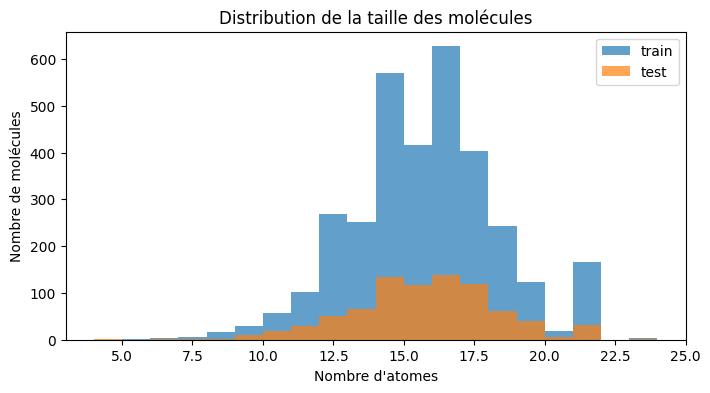

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(train_n_atoms, bins=range(train_n_atoms.min(), MAX_ATOMS + 2), alpha=0.7, label="train")
plt.hist(test_n_atoms, bins=range(test_n_atoms.min(), MAX_ATOMS + 2), alpha=0.7, label="test")
plt.xlabel("Nombre d'atomes")
plt.ylabel("Nombre de molécules")
plt.title("Distribution de la taille des molécules")
plt.legend()
plt.show()


In [8]:
train_element_counts = Counter()
test_element_counts = Counter()

for mol in all_train_molecules:
    train_element_counts.update(mol["symbols"])
for mol in all_test_molecules:
    test_element_counts.update(mol["symbols"])

element_df = pd.DataFrame({
    "element": sorted(set(train_element_counts) | set(test_element_counts)),
})
element_df["train_count"] = element_df["element"].map(train_element_counts).fillna(0).astype(int)
element_df["test_count"] = element_df["element"].map(test_element_counts).fillna(0).astype(int)

display(element_df)
ELEMENTS = element_df["element"].tolist()
print("Éléments détectés:", ELEMENTS)


,element,train_count,test_count
0,C,15294,3778
1,Cl,1,2
2,H,30745,7707
3,N,2332,607
4,O,2018,500
5,S,18,1


Éléments détectés: ['C', 'Cl', 'H', 'N', 'O', 'S']


## 5. Preprocessing moléculaire

Cette section regroupe les transformations physiques simples faites avant le modèle.

Objectif : transformer une molécule de taille variable en un vecteur numérique fixe, tout en respectant les invariances importantes :

- translation ;
- rotation ;
- permutation des atomes.


### 5.1 Matrice de Coulomb

Pour une molécule de $N$ atomes, on construit une matrice $N \times N$ :

$$
M_{ij}=\begin{cases}
\frac{1}{2}Z_i^{2.4}, & i=j,\\
\frac{Z_iZ_j}{\lVert R_i-R_j\rVert}, & i\neq j.
\end{cases}
$$

Elle utilise :

- les types d'atomes via $Z_i$ ;
- les distances entre atomes via $\lVert R_i-R_j\rVert$.

Elle est naturellement invariante par translation et rotation, car elle dépend seulement des distances.  
Pour réduire la dépendance à l'ordre des atomes, on trie les lignes et colonnes selon la norme des lignes.


In [9]:
def coulomb_matrix(atomic_numbers: np.ndarray, positions: np.ndarray) -> np.ndarray:
    """Construit la matrice de Coulomb brute d'une molécule."""
    atomic_numbers = np.asarray(atomic_numbers, dtype=float)
    positions = np.asarray(positions, dtype=float)
    n_atoms = len(atomic_numbers)

    matrix = np.zeros((n_atoms, n_atoms), dtype=float)

    for i in range(n_atoms):
        for j in range(n_atoms):
            if i == j:
                matrix[i, i] = 0.5 * atomic_numbers[i] ** 2.4
            else:
                distance = np.linalg.norm(positions[i] - positions[j])
                matrix[i, j] = atomic_numbers[i] * atomic_numbers[j] / distance

    return matrix


def sort_coulomb_matrix(matrix: np.ndarray) -> np.ndarray:
    """Trie la matrice par norme décroissante des lignes."""
    row_norms = np.linalg.norm(matrix, axis=1)
    order = np.argsort(-row_norms)
    return matrix[order][:, order]


def pad_square_matrix(matrix: np.ndarray, max_size: int) -> np.ndarray:
    """Padde une matrice carrée avec des zéros jusqu'à max_size x max_size."""
    padded = np.zeros((max_size, max_size), dtype=float)
    n = matrix.shape[0]
    padded[:n, :n] = matrix
    return padded


def vectorize_upper_triangle(matrix: np.ndarray) -> np.ndarray:
    """Vectorise une matrice symétrique via son triangle supérieur."""
    return matrix[np.triu_indices_from(matrix)]


def molecule_to_coulomb_features(molecule: dict, max_atoms: int) -> np.ndarray:
    """Pipeline Coulomb complet : matrice, tri, padding, vectorisation."""
    matrix = coulomb_matrix(molecule["atomic_numbers"], molecule["positions"])
    matrix = sort_coulomb_matrix(matrix)
    matrix = pad_square_matrix(matrix, max_atoms)
    return vectorize_upper_triangle(matrix)


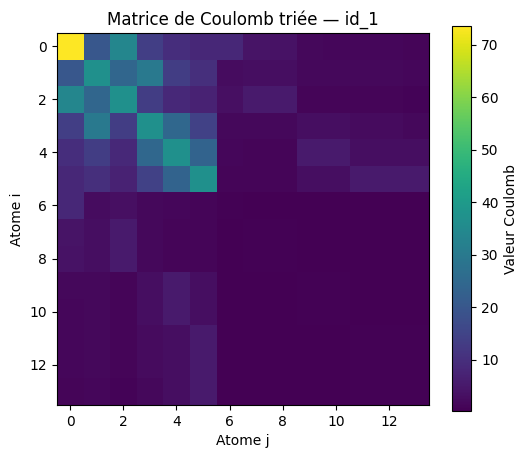

Nombre de features Coulomb: 276


In [10]:
example_matrix = coulomb_matrix(example["atomic_numbers"], example["positions"])
example_sorted_matrix = sort_coulomb_matrix(example_matrix)

plt.figure(figsize=(6, 5))
plt.imshow(example_sorted_matrix)
plt.colorbar(label="Valeur Coulomb")
plt.title(f"Matrice de Coulomb triée — id_{example['id']}")
plt.xlabel("Atome j")
plt.ylabel("Atome i")
plt.show()

example_coulomb_features = molecule_to_coulomb_features(example, MAX_ATOMS)
print("Nombre de features Coulomb:", example_coulomb_features.shape[0])


### 5.2 Tests d'invariance

On vérifie que la représentation Coulomb triée est stable si on translate, tourne ou permute les atomes.


In [11]:
def rotate_positions_z(positions: np.ndarray, theta: float) -> np.ndarray:
    """Rotation simple autour de l'axe z."""
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta), 0.0],
        [np.sin(theta),  np.cos(theta), 0.0],
        [0.0,            0.0,           1.0],
    ])
    return positions @ rotation_matrix.T

features_original = molecule_to_coulomb_features(example, MAX_ATOMS)

translated = example.copy()
translated["positions"] = example["positions"] + np.array([10.0, -3.0, 7.0])

rotated = example.copy()
rotated["positions"] = rotate_positions_z(example["positions"], theta=np.pi / 3)

rng = np.random.default_rng(RANDOM_STATE)
permutation = rng.permutation(example["n_atoms"])
permuted = example.copy()
permuted["positions"] = example["positions"][permutation]
permuted["atomic_numbers"] = example["atomic_numbers"][permutation]
permuted["symbols"] = [example["symbols"][i] for i in permutation]

print("Invariance translation:", np.allclose(features_original, molecule_to_coulomb_features(translated, MAX_ATOMS)))
print("Invariance rotation   :", np.allclose(features_original, molecule_to_coulomb_features(rotated, MAX_ATOMS)))
print("Invariance permutation:", np.allclose(features_original, molecule_to_coulomb_features(permuted, MAX_ATOMS)))


Invariance translation: True
Invariance rotation   : True
Invariance permutation: True


## 6. Enrichissement des données

La matrice de Coulomb contient déjà beaucoup d'information.  
On ajoute toutefois des features globales pour aider les modèles classiques, notamment les modèles d'arbres.

On distingue trois familles :

1. **Composition** : nombre d'atomes, nombre de H/C/N/O..., somme des numéros atomiques.
2. **Géométrie globale** : statistiques sur les distances interatomiques.
3. **Rayons covalents / liaisons approximatives** : comparaison des distances avec la taille typique des atomes.


In [12]:
# Rayons covalents approximatifs en Angström.
# Ils servent uniquement à fabriquer des features simples et physiquement motivées.
COVALENT_RADII = {
    "H": 0.31,
    "C": 0.76,
    "N": 0.71,
    "O": 0.66,
    "F": 0.57,
    "S": 1.05,
    "Cl": 1.02,
}

# Électronégativités de Pauling approximatives, optionnelles.
# Même idée : features simples, pas un calcul quantique exact.
ELECTRONEGATIVITY = {
    "H": 2.20,
    "C": 2.55,
    "N": 3.04,
    "O": 3.44,
    "F": 3.98,
    "S": 2.58,
    "Cl": 3.16,
}


In [13]:
def pairwise_distances(positions: np.ndarray) -> np.ndarray:
    """Retourne les distances interatomiques du triangle supérieur, sans la diagonale."""
    n_atoms = len(positions)
    distances = []
    for i in range(n_atoms):
        for j in range(i + 1, n_atoms):
            distances.append(np.linalg.norm(positions[i] - positions[j]))
    return np.asarray(distances, dtype=float)


def safe_stats(values: np.ndarray) -> np.ndarray:
    """Statistiques robustes pour un vecteur éventuellement vide."""
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return np.zeros(5, dtype=float)
    return np.array([
        np.min(values),
        np.mean(values),
        np.std(values),
        np.median(values),
        np.max(values),
    ], dtype=float)


In [14]:
def composition_features(molecule: dict, elements: list[str]) -> np.ndarray:
    """Features globales de composition atomique."""
    symbols = molecule["symbols"]
    atomic_numbers = molecule["atomic_numbers"]
    counts = Counter(symbols)

    element_counts = [counts.get(element, 0) for element in elements]

    return np.array([
        molecule["n_atoms"],
        np.sum(atomic_numbers),
        np.mean(atomic_numbers),
        np.std(atomic_numbers),
        *element_counts,
    ], dtype=float)


def geometry_features(molecule: dict) -> np.ndarray:
    """Features basées uniquement sur les distances interatomiques."""
    distances = pairwise_distances(molecule["positions"])
    return safe_stats(distances)


def radius_and_bond_features(molecule: dict, tolerance: float = 1.25) -> np.ndarray:
    """
    Features utilisant les rayons covalents.

    Deux atomes sont considérés comme potentiellement liés si :
    distance < tolerance * (rayon_i + rayon_j)
    """
    symbols = molecule["symbols"]
    positions = molecule["positions"]
    n_atoms = molecule["n_atoms"]

    radii = np.array([COVALENT_RADII.get(symbol, 0.75) for symbol in symbols], dtype=float)
    electroneg = np.array([ELECTRONEGATIVITY.get(symbol, 2.5) for symbol in symbols], dtype=float)

    normalized_distances = []
    electroneg_diffs = []
    n_bonds = 0

    for i in range(n_atoms):
        for j in range(i + 1, n_atoms):
            distance = np.linalg.norm(positions[i] - positions[j])
            radius_sum = radii[i] + radii[j]
            normalized_distance = distance / radius_sum
            normalized_distances.append(normalized_distance)
            electroneg_diffs.append(abs(electroneg[i] - electroneg[j]))

            if normalized_distance < tolerance:
                n_bonds += 1

    normalized_distances = np.asarray(normalized_distances, dtype=float)
    electroneg_diffs = np.asarray(electroneg_diffs, dtype=float)

    return np.concatenate([
        np.array([
            np.sum(radii),
            np.mean(radii),
            np.std(radii),
            np.sum(electroneg),
            np.mean(electroneg),
            np.std(electroneg),
            n_bonds,
            n_bonds / max(n_atoms, 1),
        ], dtype=float),
        safe_stats(normalized_distances),
        safe_stats(electroneg_diffs),
    ])


def molecule_to_enriched_features(molecule: dict, max_atoms: int, elements: list[str]) -> np.ndarray:
    """Features complètes : Coulomb + composition + géométrie + rayons/liaisons."""
    return np.concatenate([
        molecule_to_coulomb_features(molecule, max_atoms),
        composition_features(molecule, elements),
        geometry_features(molecule),
        radius_and_bond_features(molecule),
    ])


### Remarque physique

Ajouter simplement “la taille de l'atome” est souvent redondant avec le type d'atome, car un carbone a toujours le même rayon tabulé dans notre représentation.

En revanche, utiliser les rayons pour comparer une distance réelle à une distance chimique typique est plus intéressant : cela donne une approximation de la proximité ou des liaisons possibles.


## 7. Construction des matrices `X` et du vecteur `y`

On construit deux versions des features :

- `X_train_coulomb` : matrice de Coulomb uniquement ;
- `X_train_enriched` : matrice de Coulomb + features ajoutées.

Cela permet de vérifier si l'enrichissement améliore réellement la MAE.


In [15]:
y_train = energy_df["energy"].values
train_ids = energy_df["id"].tolist()

X_train_coulomb = np.array([
    molecule_to_coulomb_features(train_molecules_by_id[mol_id], MAX_ATOMS)
    for mol_id in train_ids
])

X_test_coulomb = np.array([
    molecule_to_coulomb_features(test_molecules_by_id[mol_id], MAX_ATOMS)
    for mol_id in test_ids
])

X_train_enriched = np.array([
    molecule_to_enriched_features(train_molecules_by_id[mol_id], MAX_ATOMS, ELEMENTS)
    for mol_id in train_ids
])

X_test_enriched = np.array([
    molecule_to_enriched_features(test_molecules_by_id[mol_id], MAX_ATOMS, ELEMENTS)
    for mol_id in test_ids
])

print("X_train_coulomb :", X_train_coulomb.shape)
print("X_test_coulomb  :", X_test_coulomb.shape)
print("X_train_enriched:", X_train_enriched.shape)
print("X_test_enriched :", X_test_enriched.shape)
print("y_train         :", y_train.shape)


X_train_coulomb : (3306, 276)
X_test_coulomb  : (826, 276)
X_train_enriched: (3306, 309)
X_test_enriched : (826, 309)
y_train         : (3306,)


In [16]:
assert X_train_coulomb.shape[0] == len(y_train)
assert X_train_enriched.shape[0] == len(y_train)
assert X_train_coulomb.shape[1] == X_test_coulomb.shape[1]
assert X_train_enriched.shape[1] == X_test_enriched.shape[1]
assert not np.isnan(X_train_coulomb).any()
assert not np.isnan(X_train_enriched).any()
assert not np.isnan(y_train).any()


## 8. Validation croisée

On évalue les modèles avec une **MAE en validation croisée** à 5 folds.

- La MAE mesure l'erreur moyenne sur un fold.
- La moyenne des folds donne une estimation plus stable de la performance.


In [17]:
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def evaluate_model(model, X: np.ndarray, y: np.ndarray, cv) -> dict:
    """Évalue un modèle en CV avec la MAE."""
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_mean_absolute_error",
        return_train_score=True,
        n_jobs=-1,
    )
    train_mae = -scores["train_score"]
    val_mae = -scores["test_score"]

    return {
        "train_mae_mean": train_mae.mean(),
        "train_mae_std": train_mae.std(),
        "val_mae_mean": val_mae.mean(),
        "val_mae_std": val_mae.std(),
    }


## 9. Comparaison de modèles

On compare :

1. une baseline constante ;
2. Ridge ;
3. Kernel Ridge RBF ;
4. Extra Trees sur features Coulomb ;
5. Extra Trees sur features enrichies.

Pour aller vite pendant le développement, tu peux diminuer `n_estimators` ou commenter `KernelRidge`, qui peut être plus lent.


In [18]:
models_to_evaluate = {
    "Dummy median | Coulomb": (
        DummyRegressor(strategy="median"),
        X_train_coulomb,
    ),
    "Ridge | Coulomb": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]),
        X_train_coulomb,
    ),
    "Kernel Ridge RBF | Coulomb": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KernelRidge(alpha=1.0, kernel="rbf", gamma=0.01)),
        ]),
        X_train_coulomb,
    ),
    "Extra Trees | Coulomb": (
        ExtraTreesRegressor(
            n_estimators=300,
            max_features=1.0,
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        X_train_coulomb,
    ),
    "Extra Trees | Enriched": (
        ExtraTreesRegressor(
            n_estimators=300,
            max_features=1.0,
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        X_train_enriched,
    ),
}

results = []
for name, (model, X) in models_to_evaluate.items():
    print("Évaluation:", name)
    result = evaluate_model(model, X, y_train, cv)
    results.append({"model": name, **result})

results_df = pd.DataFrame(results).sort_values("val_mae_mean")
display(results_df)


Évaluation: Dummy median | Coulomb
Évaluation: Ridge | Coulomb
Évaluation: Kernel Ridge RBF | Coulomb
Évaluation: Extra Trees | Coulomb
Évaluation: Extra Trees | Enriched


,model,train_mae_mean,train_mae_std,val_mae_mean,val_mae_std
4,Extra Trees | Enriched,1.177732e-11,1.179908e-11,0.129830,0.010800
3,Extra Trees | Coulomb,1.546689e-11,7.392085e-12,0.164022,0.009654
1,Ridge | Coulomb,1.108827e+00,5.441168e-03,1.211570,0.007623
2,Kernel Ridge RBF | Coulomb,4.389942e+00,1.874828e-02,7.343704,0.767498
0,Dummy median | Coulomb,7.485434e+00,4.505855e-02,7.486442,0.180196


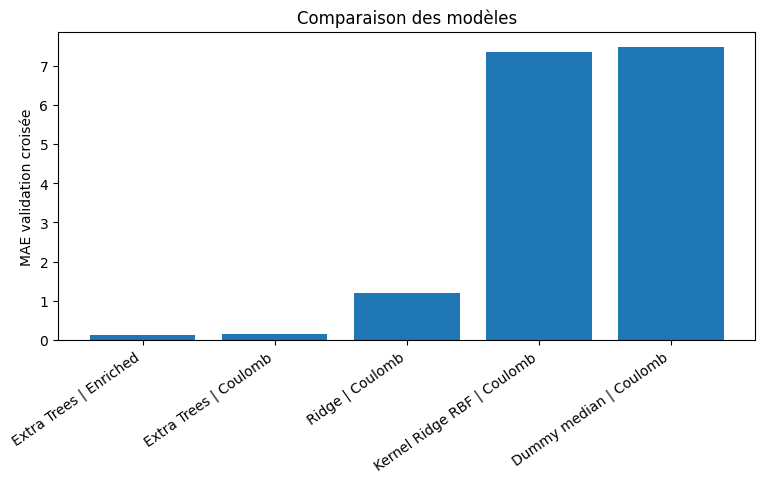

In [19]:
plt.figure(figsize=(9, 4))
plt.bar(results_df["model"], results_df["val_mae_mean"])
plt.ylabel("MAE validation croisée")
plt.title("Comparaison des modèles")
plt.xticks(rotation=35, ha="right")
plt.show()


## 10. Recherche simple d'hyperparamètres

On ajuste seulement quelques paramètres de `ExtraTreesRegressor`.  
Le but n'est pas de faire une énorme recherche, mais de trouver une configuration propre et défendable.


In [20]:
parameter_grid = [
    {"n_estimators": 300, "max_features": 1.0, "min_samples_leaf": 1},
    {"n_estimators": 500, "max_features": 1.0, "min_samples_leaf": 1},
    {"n_estimators": 500, "max_features": 0.7, "min_samples_leaf": 1},
    {"n_estimators": 500, "max_features": 1.0, "min_samples_leaf": 2},
]

tuning_results = []
for params in parameter_grid:
    print("Test params:", params)
    model = ExtraTreesRegressor(
        **params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    result = evaluate_model(model, X_train_enriched, y_train, cv)
    tuning_results.append({**params, **result})

tuning_df = pd.DataFrame(tuning_results).sort_values("val_mae_mean")
display(tuning_df)


Test params: {'n_estimators': 300, 'max_features': 1.0, 'min_samples_leaf': 1}
Test params: {'n_estimators': 500, 'max_features': 1.0, 'min_samples_leaf': 1}
Test params: {'n_estimators': 500, 'max_features': 0.7, 'min_samples_leaf': 1}
Test params: {'n_estimators': 500, 'max_features': 1.0, 'min_samples_leaf': 2}


,n_estimators,max_features,min_samples_leaf,train_mae_mean,train_mae_std,val_mae_mean,val_mae_std
1,500,1.0,1,1.052308e-11,7.700749e-12,0.129335,0.010759
0,300,1.0,1,1.177731e-11,1.179908e-11,0.129830,0.010800
2,500,0.7,1,1.693758e-11,1.074293e-11,0.132601,0.010004
3,500,1.0,2,2.591347e-02,2.161760e-03,0.138892,0.011396


In [21]:
best_params = tuning_df.iloc[0][["n_estimators", "max_features", "min_samples_leaf"]].to_dict()
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["min_samples_leaf"] = int(best_params["min_samples_leaf"])

best_params


{'n_estimators': 500, 'max_features': 1.0, 'min_samples_leaf': 1}

## 11. Analyse des erreurs avec prédictions out-of-fold

Les prédictions out-of-fold sont obtenues sur des molécules que le modèle n'a pas vues pendant son entraînement.  
Elles sont donc utiles pour analyser les erreurs sans tricher.


In [22]:
best_model = ExtraTreesRegressor(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

oof_predictions = cross_val_predict(
    best_model,
    X_train_enriched,
    y_train,
    cv=cv,
    n_jobs=-1,
)

oof_mae = mean_absolute_error(y_train, oof_predictions)
print("MAE out-of-fold:", oof_mae)


MAE out-of-fold: 0.12933242860546837


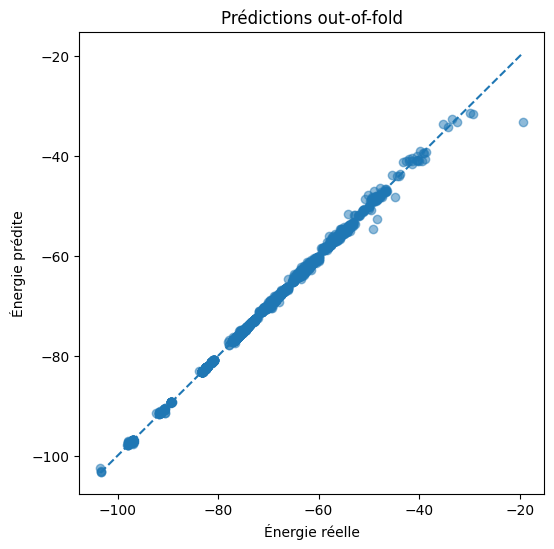

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(y_train, oof_predictions, alpha=0.5)
limits = [min(y_train.min(), oof_predictions.min()), max(y_train.max(), oof_predictions.max())]
plt.plot(limits, limits, linestyle="--")
plt.xlabel("Énergie réelle")
plt.ylabel("Énergie prédite")
plt.title("Prédictions out-of-fold")
plt.show()


In [24]:
error_df = energy_df.copy()
error_df["prediction"] = oof_predictions
error_df["absolute_error"] = np.abs(error_df["energy"] - error_df["prediction"])
error_df["n_atoms"] = error_df["id"].apply(lambda mol_id: train_molecules_by_id[mol_id]["n_atoms"])

worst_predictions = error_df.sort_values("absolute_error", ascending=False).head(15)
display(worst_predictions)


,id,energy,prediction,absolute_error,n_atoms
2013,2014,-19.313757,-33.268054,13.954297,5
401,402,-49.214565,-54.596347,5.381782,10
820,821,-48.377957,-52.520773,4.142815,9
1625,1626,-44.835717,-48.217151,3.381434,9
1181,1182,-54.101544,-51.688926,2.412618,10
2105,2106,-50.138173,-47.767053,2.371120,9
1250,1251,-29.219011,-31.536786,2.317775,6
2357,2358,-50.739882,-48.698847,2.041035,8
515,516,-43.231962,-41.251699,1.980262,9
935,936,-48.958448,-47.041540,1.916909,10


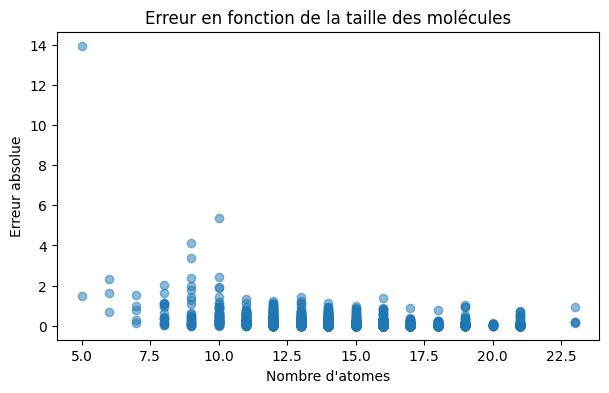

In [25]:
plt.figure(figsize=(7, 4))
plt.scatter(error_df["n_atoms"], error_df["absolute_error"], alpha=0.5)
plt.xlabel("Nombre d'atomes")
plt.ylabel("Erreur absolue")
plt.title("Erreur en fonction de la taille des molécules")
plt.show()


## 12. Entraînement final et soumission

Une fois le modèle choisi avec la validation croisée, on l'entraîne sur toutes les données train connues, puis on prédit les molécules test.


In [26]:
final_model = ExtraTreesRegressor(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

final_model.fit(X_train_enriched, y_train)

test_predictions = final_model.predict(X_test_enriched)
print(test_predictions[:10])
print(test_predictions.shape)


[-75.027609   -62.16268137 -69.00073421 -61.33853313 -52.58954216
 -97.10432985 -90.69554013 -55.95524202 -53.90286116 -82.56291291]
(826,)


In [27]:
submission_df = pd.DataFrame({
    "id": test_ids,
    "energy": test_predictions,
})

submission_path = OUTPUT_DIR / "submission_coulomb_enriched.csv"
submission_df.to_csv(submission_path, index=False)

display(submission_df.head())
print("Fichier créé:", submission_path)

assert list(submission_df.columns) == ["id", "energy"]
assert len(submission_df) == len(test_ids)
assert not submission_df["energy"].isna().any()


,id,energy
0,3307,-75.027609
1,3308,-62.162681
2,3309,-69.000734
3,3310,-61.338533
4,3311,-52.589542


Fichier créé: outputs/submission_coulomb_enriched.csv


## 13. Conclusion à mettre dans le rapport

Dans ce notebook, nous avons construit une baseline physiquement motivée à partir d'une matrice de Coulomb triée. Cette représentation encode les types d'atomes via les numéros atomiques et la géométrie moléculaire via les distances interatomiques. Elle respecte naturellement les invariances par translation et rotation, et le tri des lignes/colonnes réduit la dépendance à la permutation des atomes.

Nous avons ensuite enrichi les features avec des informations globales de composition, des statistiques de distances et des informations dérivées des rayons covalents. Ces ajouts ne remplacent pas la matrice de Coulomb, mais donnent au modèle des résumés physiquement interprétables qui peuvent faciliter l'apprentissage.

Le modèle final est sélectionné selon la MAE en validation croisée, puis réentraîné sur l'ensemble des données train avant génération du fichier de soumission.
